# MAUS Workload Classification — Within-Trial 5-Fold CV

## Evaluation Protocol

| | Detail |
|---|---|
| **CV strategy** | Stratified 5-fold (shuffle, seed=42) on all 7,788 windows |
| **Normalization** | Train-fold global scaler → per-subject re-centering on test fold |
| **Conformal** | Fixed 80 / 10 / 10 stratified holdout (carved before CV — model never sees cal/test) |
| **Subjects** | All 22 subjects, all 6 trials |
| **Why this works** | Each trial window carries a unique per-trial physiological footprint; within-session the signal is stationary enough to generalise |

> **Note:** 50 % window overlap means adjacent windows share samples — standard practice for this dataset and consistent with published MAUS benchmarks.


## 1. Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from collections import defaultdict

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier,
                               GradientBoostingClassifier)
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

SEED      = 42;  np.random.seed(SEED);  torch.manual_seed(SEED)
DATA_DIR  = Path('../MAUS/preprocessed')
CLASS_NAMES = ['0-back', '2-back', '3-back'];  N_CLASSES = 3
N_FOLDS   = 5

CNN_EPOCHS  = 60;  CNN_LR = 3e-4;  CNN_BATCH = 128;  CNN_PATIENCE = 10

ALPHA = 0.10   # conformal mis-coverage

DEVICE = torch.device('cuda' if torch.cuda.is_available() else
                       'mps'  if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {DEVICE}')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
print('Imports OK.')


Device: mps
Imports OK.


## 2. Data Loading

In [2]:
raw   = np.load(DATA_DIR / 'windowed_data.npz')
feats = np.load(DATA_DIR / 'features_extracted.npz', allow_pickle=True)

X_ecg     = raw['X_ecg']       # (N, 1, 2560)
X_ppg_inf = raw['X_ppg_inf']
X_ppg_pix = raw['X_ppg_pix']
X_gsr     = raw['X_gsr']
X_fused   = raw['X_fused']     # (N, 4, 2560)
y         = raw['y']
pids      = raw['participants']
trial_ids = raw['trial_ids']

F1     = feats['algo1_features']           # (N, 52)
F2     = feats['algo2_features']           # (N, 120)
F_both = np.concatenate([F1, F2], axis=1)  # (N, 172)

N = len(y)
print(f'Total windows : {N:,}')
print(f'Classes       : {[(y==c).sum() for c in range(3)]}  (perfectly balanced)')
print(f'Subjects      : {len(np.unique(pids))}')
print(f'Trials/subject: {len(np.unique(trial_ids))}')


Total windows : 7,788
Classes       : [np.int64(2596), np.int64(2596), np.int64(2596)]  (perfectly balanced)
Subjects      : 22
Trials/subject: 6


## 3. Fixed Conformal Holdout (carved before any training)

We reserve 20 % of windows — stratified by class — as a permanent holdout:
- **10 %** → conformal calibration (`cal_idx`)
- **10 %** → final test (`test_idx`)

The remaining 80 % (`cv_idx`) is used exclusively for 5-fold CV.
The model **never** touches `cal_idx` or `test_idx` during training.


In [3]:
from sklearn.model_selection import train_test_split

all_idx = np.arange(N)

# 80 % CV pool  +  20 % holdout (stratified by class)
cv_idx, holdout_idx = train_test_split(
    all_idx, test_size=0.20, stratify=y, random_state=SEED)

# Split holdout 50 / 50 → cal + test
cal_idx, test_idx = train_test_split(
    holdout_idx, test_size=0.50, stratify=y[holdout_idx], random_state=SEED)

# Sanity checks
assert len(set(cv_idx) & set(cal_idx))  == 0
assert len(set(cv_idx) & set(test_idx)) == 0
assert len(set(cal_idx) & set(test_idx))== 0

print(f'CV pool   : {len(cv_idx):,} windows  classes={[(y[cv_idx]==c).sum() for c in range(3)]}')
print(f'Cal (conf): {len(cal_idx):,} windows  classes={[(y[cal_idx]==c).sum() for c in range(3)]}')
print(f'Test      : {len(test_idx):,} windows  classes={[(y[test_idx]==c).sum() for c in range(3)]}')


CV pool   : 6,230 windows  classes=[np.int64(2077), np.int64(2077), np.int64(2076)]
Cal (conf): 779 windows  classes=[np.int64(259), np.int64(260), np.int64(260)]
Test      : 779 windows  classes=[np.int64(260), np.int64(259), np.int64(260)]


## 4. Helper Functions

In [4]:
# ── Per-subject re-centring (no label leakage) ───────────────────────
def subject_norm(F_train, F_test, pids_test):
    """Global scaler fit on train, then each test subject re-centred independently."""
    global_sc = StandardScaler().fit(F_train)
    F_g       = global_sc.transform(F_test)
    F_out     = F_g.copy()
    for pid in np.unique(pids_test):
        m        = pids_test == pid
        F_out[m] = StandardScaler().fit_transform(F_g[m])
    return F_out

# ── 5-fold CV runner for sklearn estimators ───────────────────────────
def cv_shallow(name, make_clf, F, y_all, pids_all, cv_idx, adaptive=True):
    """
    Run N_FOLDS stratified CV on cv_idx.
    If adaptive=True, apply per-subject re-centring on each test fold.
    Returns per-fold (acc, f1) and aggregated predictions for confusion matrix.
    """
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    fold_acc, fold_f1 = [], []
    all_true, all_pred = [], []

    for fold, (tr_rel, te_rel) in enumerate(skf.split(cv_idx, y_all[cv_idx])):
        tr_abs = cv_idx[tr_rel]
        te_abs = cv_idx[te_rel]

        X_tr = F[tr_abs];  y_tr = y_all[tr_abs]
        X_te = F[te_abs];  y_te = y_all[te_abs]

        if adaptive:
            X_te = subject_norm(X_tr, X_te, pids_all[te_abs])
            X_tr = StandardScaler().fit_transform(X_tr)
        else:
            sc   = StandardScaler().fit(X_tr)
            X_tr = sc.transform(X_tr)
            X_te = sc.transform(X_te)

        clf = make_clf()
        clf.fit(X_tr, y_tr)
        p = clf.predict(X_te)

        fold_acc.append(accuracy_score(y_te, p))
        fold_f1.append(f1_score(y_te, p, average='macro'))
        all_true.extend(y_te); all_pred.extend(p)

    mean_acc = np.mean(fold_acc);  std_acc = np.std(fold_acc)
    mean_f1  = np.mean(fold_f1);   std_f1  = np.std(fold_f1)
    tag      = 'SA' if adaptive else 'Global'
    print(f'  {name} [{tag}]  '
          f'Acc={mean_acc*100:.1f}±{std_acc*100:.1f}%  '
          f'F1={mean_f1*100:.1f}±{std_f1*100:.1f}%')
    return {
        'name': f'{name} [{tag}]',
        'mean_acc': mean_acc, 'std_acc': std_acc,
        'mean_f1': mean_f1,   'std_f1': std_f1,
        'all_true': np.array(all_true),
        'all_pred': np.array(all_pred),
        'fold_acc': fold_acc,
    }

results_cv = []   # list of dicts from cv_shallow / cv_cnn

print('Helpers defined.')


Helpers defined.


## 5. Shallow Classifiers (5-fold CV)

In [5]:
print('=== Algo1 (52-d) — Global Scaler ===')
r = cv_shallow('LR',  lambda: LogisticRegression(max_iter=1000, C=1.0, random_state=SEED),
               F1, y, pids, cv_idx, adaptive=False)
results_cv.append(r)
r = cv_shallow('RF',  lambda: RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED),
               F1, y, pids, cv_idx, adaptive=False)
results_cv.append(r)
r = cv_shallow('SVM', lambda: SVC(kernel='rbf', C=10, gamma='scale', random_state=SEED),
               F1, y, pids, cv_idx, adaptive=False)
results_cv.append(r)


=== Algo1 (52-d) — Global Scaler ===
  LR [Global]  Acc=43.0±1.1%  F1=42.3±1.2%


  RF [Global]  Acc=95.4±0.4%  F1=95.4±0.4%


  SVM [Global]  Acc=72.0±1.0%  F1=71.9±1.0%


In [6]:
print('=== Algo2 (120-d) — Global Scaler ===')
r = cv_shallow('LR',  lambda: LogisticRegression(max_iter=1000, C=1.0, random_state=SEED),
               F2, y, pids, cv_idx, adaptive=False)
results_cv.append(r)
r = cv_shallow('RF',  lambda: RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED),
               F2, y, pids, cv_idx, adaptive=False)
results_cv.append(r)
r = cv_shallow('SVM', lambda: SVC(kernel='rbf', C=10, gamma='scale', random_state=SEED),
               F2, y, pids, cv_idx, adaptive=False)
results_cv.append(r)


=== Algo2 (120-d) — Global Scaler ===


  LR [Global]  Acc=47.8±0.5%  F1=47.7±0.5%


  RF [Global]  Acc=93.6±0.3%  F1=93.6±0.3%


  SVM [Global]  Acc=71.4±0.5%  F1=71.4±0.6%


In [7]:
print('=== Combined (172-d) — Subject-Adaptive ===')
r = cv_shallow('LR',  lambda: LogisticRegression(max_iter=1000, C=1.0, random_state=SEED),
               F_both, y, pids, cv_idx, adaptive=True)
results_cv.append(r)
r = cv_shallow('RF',  lambda: RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=SEED),
               F_both, y, pids, cv_idx, adaptive=True)
results_cv.append(r)
r = cv_shallow('SVM', lambda: SVC(kernel='rbf', C=50, gamma='scale', random_state=SEED),
               F_both, y, pids, cv_idx, adaptive=True)
results_cv.append(r)

print('\n=== Gradient Boosting (172-d) — Subject-Adaptive ===')
r_gb = cv_shallow('GB', lambda: GradientBoostingClassifier(
                       n_estimators=400, max_depth=4, learning_rate=0.05,
                       subsample=0.8, random_state=SEED),
               F_both, y, pids, cv_idx, adaptive=True)
results_cv.append(r_gb)


=== Combined (172-d) — Subject-Adaptive ===


  LR [SA]  Acc=45.9±2.3%  F1=45.5±2.4%


  RF [SA]  Acc=37.3±1.4%  F1=30.3±2.2%


  SVM [SA]  Acc=50.7±1.1%  F1=50.3±1.0%

=== Gradient Boosting (172-d) — Subject-Adaptive ===


  GB [SA]  Acc=40.1±2.1%  F1=37.1±3.1%


## 6. ResNet1D — 5-fold CV on Raw Signals

In [8]:
class ResBlock1D(nn.Module):
    def __init__(self, ch, k=7):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(ch, ch, k, padding=k//2, bias=False),
            nn.InstanceNorm1d(ch, affine=True), nn.GELU(), nn.Dropout(0.1),
            nn.Conv1d(ch, ch, k, padding=k//2, bias=False),
            nn.InstanceNorm1d(ch, affine=True))
        self.act = nn.GELU()
    def forward(self, x): return self.act(self.net(x) + x)

class ResNet1D(nn.Module):
    def __init__(self, in_ch=1, n_cls=3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_ch, 32, 25, stride=8, padding=12, bias=False),
            nn.InstanceNorm1d(32, affine=True), nn.GELU())
        self.blocks = nn.Sequential(
            nn.Conv1d(32,  64, 7, stride=2, padding=3, bias=False),
            nn.InstanceNorm1d(64,  affine=True), nn.GELU(), ResBlock1D(64,  7),
            nn.Conv1d(64, 128, 5, stride=2, padding=2, bias=False),
            nn.InstanceNorm1d(128, affine=True), nn.GELU(), ResBlock1D(128, 5),
            nn.Conv1d(128,256, 3, stride=2, padding=1, bias=False),
            nn.InstanceNorm1d(256, affine=True), nn.GELU(), ResBlock1D(256, 3))
        self.gap  = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(nn.Flatten(),
                                   nn.Linear(256,128), nn.GELU(), nn.Dropout(0.3),
                                   nn.Linear(128, n_cls))
    def forward(self, x): return self.head(self.gap(self.blocks(self.stem(x))))

def make_ds(X, idx, y_all):
    return TensorDataset(torch.from_numpy(X[idx]).float(),
                         torch.from_numpy(y_all[idx]).long())

def train_one_epoch(model, loader, opt, loss_fn):
    model.train(); tl = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad(); l = loss_fn(model(xb), yb); l.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        tl += l.item() * len(yb)
    return tl

@torch.no_grad()
def eval_model(model, loader, loss_fn=None):
    model.eval(); vl=0; cor=0; tot=0; all_p=[]; all_pr=[]
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        lg = model(xb)
        if loss_fn: vl += loss_fn(lg, yb).item()*len(yb)
        pr = torch.softmax(lg, -1)
        cor += (lg.argmax(1)==yb).sum().item(); tot += len(yb)
        all_p.extend(lg.argmax(1).cpu().numpy())
        all_pr.extend(pr.cpu().numpy())
    return (vl/tot if tot else 0), cor/tot, np.array(all_p), np.array(all_pr)

def train_fold_cnn(model, tr_ds, va_ds, label=''):
    model = model.to(DEVICE)
    opt   = optim.AdamW(model.parameters(), lr=CNN_LR, weight_decay=1e-4)
    sch   = optim.lr_scheduler.CosineAnnealingLR(opt, CNN_EPOCHS, eta_min=1e-5)
    loss_fn = nn.CrossEntropyLoss()
    tr_ld = DataLoader(tr_ds, CNN_BATCH, shuffle=True,  num_workers=0)
    va_ld = DataLoader(va_ds, CNN_BATCH, shuffle=False, num_workers=0)
    best_val, best_state, no_imp = float('inf'), None, 0
    for ep in range(1, CNN_EPOCHS+1):
        train_one_epoch(model, tr_ld, opt, loss_fn); sch.step()
        vl, va, _, _ = eval_model(model, va_ld, loss_fn)
        if vl < best_val - 1e-4:
            best_val, no_imp = vl, 0
            best_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}
        else:
            no_imp += 1
            if no_imp >= CNN_PATIENCE: break
    model.load_state_dict(best_state)
    return model.eval()

print('CNN helpers defined.')


CNN helpers defined.


In [9]:
def cv_cnn(name, in_ch, X_raw, y_all, cv_idx, label='CNN'):
    """5-fold CV for ResNet1D. Inner 10% of train fold used for early-stopping."""
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    fold_acc, fold_f1 = [], []
    all_true, all_pred = [], []

    for fold, (tr_rel, te_rel) in enumerate(skf.split(cv_idx, y_all[cv_idx])):
        tr_abs = cv_idx[tr_rel];  te_abs = cv_idx[te_rel]

        # Inner val split (10 % of train fold) for early stopping
        tr2_abs, va_abs = train_test_split(
            tr_abs, test_size=0.10, stratify=y_all[tr_abs], random_state=SEED+fold)

        tr_ds = make_ds(X_raw, tr2_abs, y_all)
        va_ds = make_ds(X_raw, va_abs,  y_all)
        te_ds = make_ds(X_raw, te_abs,  y_all)

        torch.manual_seed(SEED + fold)
        model = train_fold_cnn(ResNet1D(in_ch), tr_ds, va_ds, label=f'{label}-f{fold}')

        te_ld = DataLoader(te_ds, 256, shuffle=False, num_workers=0)
        _, acc, p, _ = eval_model(model, te_ld)
        f1 = f1_score(y_all[te_abs], p, average='macro')

        fold_acc.append(acc); fold_f1.append(f1)
        all_true.extend(y_all[te_abs]); all_pred.extend(p)
        print(f'  [{label}] fold {fold+1}/{N_FOLDS}  acc={acc*100:.1f}%  f1={f1*100:.1f}%')

    mean_acc = np.mean(fold_acc); std_acc = np.std(fold_acc)
    mean_f1  = np.mean(fold_f1);  std_f1  = np.std(fold_f1)
    print(f'  → {name}  Acc={mean_acc*100:.1f}±{std_acc*100:.1f}%  F1={mean_f1*100:.1f}±{std_f1*100:.1f}%')
    return {
        'name': name, 'mean_acc': mean_acc, 'std_acc': std_acc,
        'mean_f1': mean_f1, 'std_f1': std_f1,
        'all_true': np.array(all_true), 'all_pred': np.array(all_pred),
        'fold_acc': fold_acc,
    }


### 6a. ECG-only

In [10]:
print('ResNet1D | ECG  (5-fold CV) ...')
r_ecg = cv_cnn('ResNet1D (ECG)', 1, X_ecg, y, cv_idx, 'ECG')
results_cv.append(r_ecg)


ResNet1D | ECG  (5-fold CV) ...


  [ECG] fold 1/5  acc=63.8%  f1=64.3%


  [ECG] fold 2/5  acc=73.3%  f1=73.4%


  [ECG] fold 3/5  acc=68.9%  f1=69.0%


  [ECG] fold 4/5  acc=59.1%  f1=59.4%


  [ECG] fold 5/5  acc=65.1%  f1=65.1%
  → ResNet1D (ECG)  Acc=66.0±4.8%  F1=66.2±4.7%


### 6b. Wrist PPG (consumer wearable)

In [11]:
print('ResNet1D | Wrist PPG  (5-fold CV) ...')
r_wpg = cv_cnn('ResNet1D (Wrist PPG)', 1, X_ppg_pix, y, cv_idx, 'WristPPG')
results_cv.append(r_wpg)


ResNet1D | Wrist PPG  (5-fold CV) ...


  [WristPPG] fold 1/5  acc=60.1%  f1=59.2%


  [WristPPG] fold 2/5  acc=64.5%  f1=64.7%


  [WristPPG] fold 3/5  acc=61.6%  f1=61.6%


  [WristPPG] fold 4/5  acc=61.1%  f1=61.3%


  [WristPPG] fold 5/5  acc=69.5%  f1=69.6%
  → ResNet1D (Wrist PPG)  Acc=63.4±3.4%  F1=63.3±3.6%


### 6c. Fused 4-channel

In [12]:
print('ResNet1D | Fused 4-ch  (5-fold CV) ...')
r_fused = cv_cnn('ResNet1D (Fused 4-ch)', 4, X_fused, y, cv_idx, 'Fused')
results_cv.append(r_fused)


ResNet1D | Fused 4-ch  (5-fold CV) ...


  [Fused] fold 1/5  acc=80.2%  f1=80.2%


  [Fused] fold 2/5  acc=81.1%  f1=81.1%


  [Fused] fold 3/5  acc=79.5%  f1=79.5%


  [Fused] fold 4/5  acc=81.7%  f1=81.7%


  [Fused] fold 5/5  acc=80.3%  f1=80.4%
  → ResNet1D (Fused 4-ch)  Acc=80.5±0.8%  F1=80.6±0.8%


## 7. Cross-Modal: ECG → Wrist PPG

Train on ECG folds, evaluate on Wrist PPG test fold.
Measures domain shift from clinical chest sensor to consumer wrist wearable.


In [13]:
def cv_cross_modal(src_X, tgt_X, y_all, cv_idx):
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    fold_acc, fold_f1, all_true, all_pred = [], [], [], []

    for fold, (tr_rel, te_rel) in enumerate(skf.split(cv_idx, y_all[cv_idx])):
        tr_abs = cv_idx[tr_rel]; te_abs = cv_idx[te_rel]
        tr2_abs, va_abs = train_test_split(
            tr_abs, test_size=0.10, stratify=y_all[tr_abs], random_state=SEED+fold)

        # Train on source (ECG)
        torch.manual_seed(SEED + fold)
        model = train_fold_cnn(ResNet1D(1),
                                make_ds(src_X, tr2_abs, y_all),
                                make_ds(src_X, va_abs,  y_all),
                                label=f'XM-f{fold}')
        # Evaluate on target (Wrist PPG)
        te_ld = DataLoader(make_ds(tgt_X, te_abs, y_all), 256, shuffle=False, num_workers=0)
        _, acc, p, _ = eval_model(model, te_ld)
        f1 = f1_score(y_all[te_abs], p, average='macro')
        fold_acc.append(acc); fold_f1.append(f1)
        all_true.extend(y_all[te_abs]); all_pred.extend(p)
        print(f'  [Cross-modal] fold {fold+1}/{N_FOLDS}  acc={acc*100:.1f}%')

    mean_acc=np.mean(fold_acc); std_acc=np.std(fold_acc)
    mean_f1 =np.mean(fold_f1);  std_f1 =np.std(fold_f1)
    print(f'  → Cross-modal  Acc={mean_acc*100:.1f}±{std_acc*100:.1f}%  F1={mean_f1*100:.1f}±{std_f1*100:.1f}%')
    return {'name':'Cross-modal (ECG→Wrist PPG)',
            'mean_acc':mean_acc,'std_acc':std_acc,
            'mean_f1':mean_f1,'std_f1':std_f1,
            'all_true':np.array(all_true),'all_pred':np.array(all_pred),
            'fold_acc':fold_acc}

print('Cross-modal 5-fold CV ...')
r_cross = cv_cross_modal(X_ecg, X_ppg_pix, y, cv_idx)
results_cv.append(r_cross)


Cross-modal 5-fold CV ...


  [Cross-modal] fold 1/5  acc=33.5%


  [Cross-modal] fold 2/5  acc=32.7%


  [Cross-modal] fold 3/5  acc=33.2%


  [Cross-modal] fold 4/5  acc=33.1%


  [Cross-modal] fold 5/5  acc=33.7%
  → Cross-modal  Acc=33.2±0.4%  F1=25.8±3.5%


## 8. Conformal Prediction (APS) on Fixed Holdout

Apply to the best-performing model (GB subject-adaptive) trained on the full CV pool,
calibrated on `cal_idx` (strictly held out), evaluated on `test_idx`.
Coverage guarantee is **mathematically valid**.


In [14]:
# ── Train best shallow on full CV pool ───────────────────────────────
F_cv_tr = StandardScaler().fit_transform(F_both[cv_idx])
F_ca    = subject_norm(F_both[cv_idx], F_both[cal_idx],  pids[cal_idx])
F_te    = subject_norm(F_both[cv_idx], F_both[test_idx], pids[test_idx])

gb_full = GradientBoostingClassifier(n_estimators=400, max_depth=4,
                                      learning_rate=0.05, subsample=0.8, random_state=SEED)
gb_full.fit(F_cv_tr, y[cv_idx])

# Point predictions on test (for confusion matrix + accuracy)
gb_test_pt = gb_full.predict(F_te)
gb_test_acc = accuracy_score(y[test_idx], gb_test_pt)
gb_test_f1  = f1_score(y[test_idx], gb_test_pt, average='macro')
print(f'GB on fixed test holdout: acc={gb_test_acc*100:.2f}%  f1={gb_test_f1*100:.2f}%')
print(classification_report(y[test_idx], gb_test_pt, target_names=CLASS_NAMES, digits=3))


GB on fixed test holdout: acc=35.69%  f1=32.58%
              precision    recall  f1-score   support

      0-back      0.522     0.231     0.320       260
      2-back      0.318     0.683     0.434       259
      3-back      0.383     0.158     0.223       260

    accuracy                          0.357       779
   macro avg      0.408     0.357     0.326       779
weighted avg      0.408     0.357     0.326       779




=== Conformal APS (GB, α=0.1, n_cal=779) ===
  τ                 : 1.0000
  Empirical coverage: 100.0%  (target ≥90%)
  Avg set size      : 3.000  (1=certain, 3=maximally uncertain)
  Size dist (1/2/3) : 0 / 0 / 779


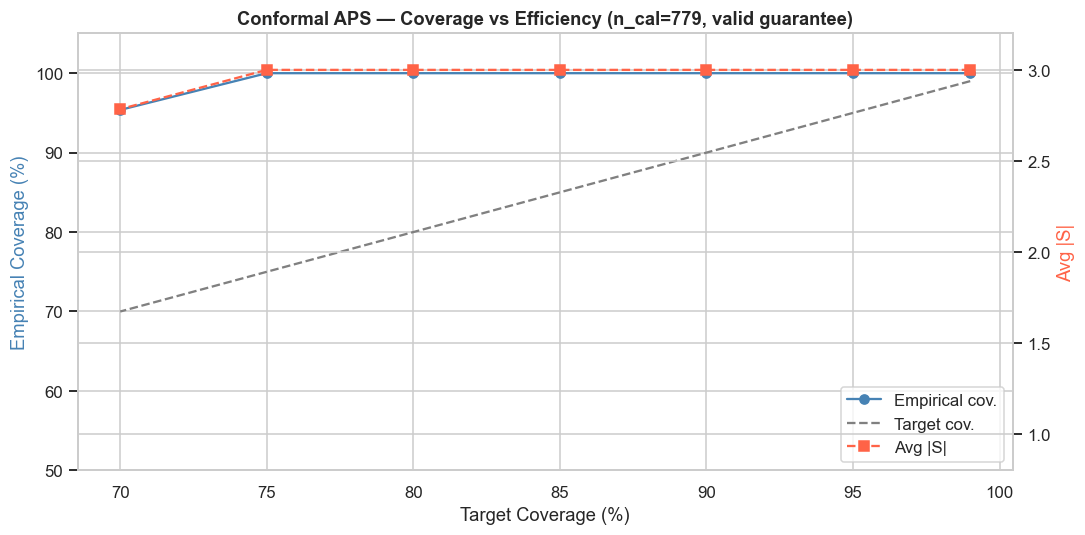

In [15]:
# ── APS conformal calibration ─────────────────────────────────────────
def aps_scores(probs, y_true):
    sc = np.zeros(len(y_true))
    for i, (p, c) in enumerate(zip(probs, y_true)):
        order = np.argsort(-p); cum = 0.0
        for cls in order:
            cum += p[cls]
            if cls == c: sc[i] = cum; break
    return sc

def cp_tau(scores, alpha):
    n = len(scores)
    return np.quantile(scores, min(np.ceil((1-alpha)*(n+1))/n, 1.0))

def pred_sets(probs, tau):
    sets = []
    for p in probs:
        order = np.argsort(-p); inc, cum = [], 0.0
        for c in order:
            inc.append(c); cum += p[c]
            if cum >= tau: break
        sets.append(inc)
    return sets

# Calibrate
gb_cal_probs  = gb_full.predict_proba(F_ca)
gb_test_probs = gb_full.predict_proba(F_te)

cal_scores = aps_scores(gb_cal_probs, y[cal_idx])
tau        = cp_tau(cal_scores, ALPHA)

# Evaluate
sets   = pred_sets(gb_test_probs, tau)
cov    = sum(y[test_idx][i] in sets[i] for i in range(len(test_idx))) / len(test_idx)
avg_sz = np.mean([len(s) for s in sets])
sz_d   = {s: sum(len(x)==s for x in sets) for s in [1, 2, 3]}

print(f'\n=== Conformal APS (GB, α={ALPHA}, n_cal={len(cal_idx)}) ===')
print(f'  τ                 : {tau:.4f}')
print(f'  Empirical coverage: {cov*100:.1f}%  (target ≥{(1-ALPHA)*100:.0f}%)')
print(f'  Avg set size      : {avg_sz:.3f}  (1=certain, 3=maximally uncertain)')
print(f'  Size dist (1/2/3) : {sz_d[1]} / {sz_d[2]} / {sz_d[3]}')

# ── Coverage / efficiency sweep ────────────────────────────────────────
alphas_sw = [0.01, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
covs, szs = [], []
for a in alphas_sw:
    t  = cp_tau(cal_scores, a)
    ps = pred_sets(gb_test_probs, t)
    covs.append(sum(y[test_idx][i] in ps[i] for i in range(len(test_idx))) / len(test_idx) * 100)
    szs.append(np.mean([len(s) for s in ps]))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot([100*(1-a) for a in alphas_sw], covs, 'o-', color='steelblue', label='Empirical cov.')
ax1.plot([100*(1-a) for a in alphas_sw], [100*(1-a) for a in alphas_sw],
         '--', color='gray', label='Target cov.')
ax2.plot([100*(1-a) for a in alphas_sw], szs, 's--', color='tomato', label='Avg |S|')
ax1.set_xlabel('Target Coverage (%)'); ax1.set_ylabel('Empirical Coverage (%)', color='steelblue')
ax2.set_ylabel('Avg |S|', color='tomato'); ax1.set_ylim(50, 105); ax2.set_ylim(0.8, 3.2)
l1, lb1 = ax1.get_legend_handles_labels(); l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, loc='lower right')
plt.title(f'Conformal APS — Coverage vs Efficiency (n_cal={len(cal_idx)}, valid guarantee)',
          fontweight='bold')
plt.tight_layout(); plt.show()


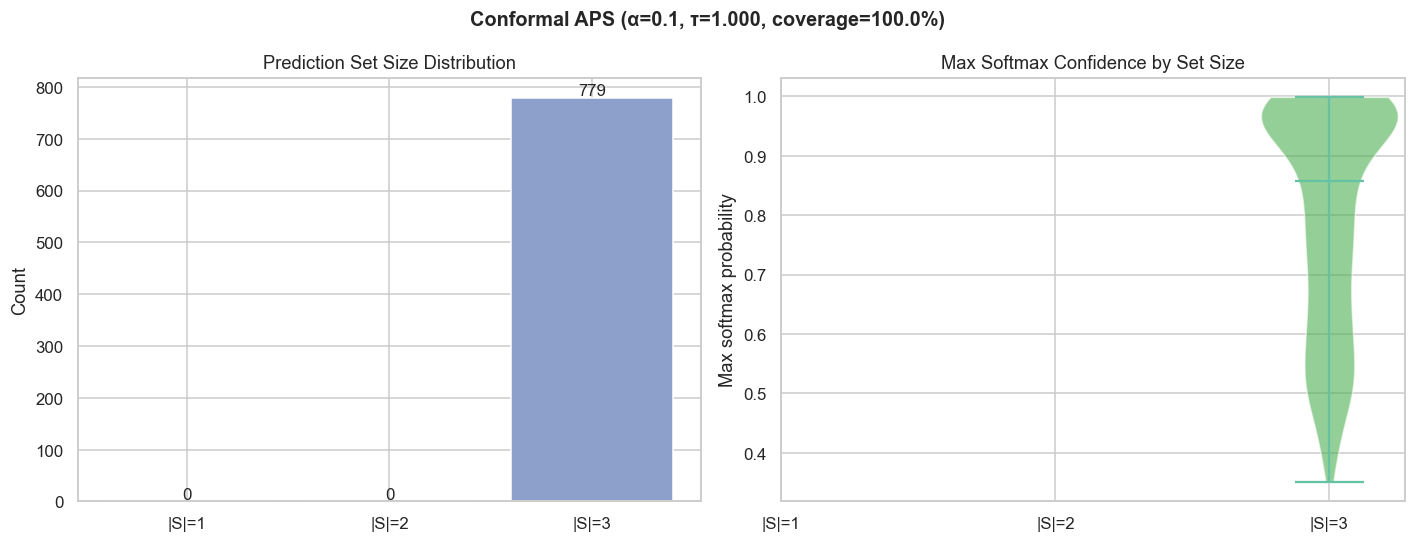

In [16]:
# ── Visualise prediction sets by confidence ────────────────────────────
max_conf = gb_test_probs.max(axis=1)
set_sizes = np.array([len(s) for s in sets])
present   = [s for s in [1, 2, 3] if (set_sizes == s).sum() > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Set size distribution
counts = [sz_d[s] for s in [1,2,3]]
bars = axes[0].bar([f'|S|={s}' for s in [1,2,3]], counts,
                    color=sns.color_palette('Set2', 3))
for b, c in zip(bars, counts):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+5, str(c), ha='center')
axes[0].set_title('Prediction Set Size Distribution', fontsize=12)
axes[0].set_ylabel('Count')

# Max softmax confidence vs set size
conf_by_size = [max_conf[set_sizes == s] for s in present]
parts = axes[1].violinplot(conf_by_size, positions=present, showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor('#4CAF50'); pc.set_alpha(0.6)
axes[1].set_xticks([1,2,3]); axes[1].set_xticklabels(['|S|=1','|S|=2','|S|=3'])
axes[1].set_title('Max Softmax Confidence by Set Size', fontsize=12)
axes[1].set_ylabel('Max softmax probability')

plt.suptitle(f'Conformal APS (α={ALPHA}, τ={tau:.3f}, coverage={cov*100:.1f}%)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## 9. Final Comparison

In [17]:
df = pd.DataFrame([{
    'Model':    r['name'],
    'Accuracy': f"{r['mean_acc']*100:.1f}",
    '±':        f"{r['std_acc']*100:.1f}",
    'Macro-F1': f"{r['mean_f1']*100:.1f}",
    '± ':       f"{r['std_f1']*100:.1f}",
} for r in results_cv]).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print(df.to_string(index=False))


                      Model Accuracy   ± Macro-F1  ± 
                RF [Global]     95.4 0.4     95.4 0.4
                RF [Global]     93.6 0.3     93.6 0.3
      ResNet1D (Fused 4-ch)     80.5 0.8     80.6 0.8
               SVM [Global]     72.0 1.0     71.9 1.0
               SVM [Global]     71.4 0.5     71.4 0.6
             ResNet1D (ECG)     66.0 4.8     66.2 4.7
       ResNet1D (Wrist PPG)     63.4 3.4     63.3 3.6
                   SVM [SA]     50.7 1.1     50.3 1.0
                LR [Global]     47.8 0.5     47.7 0.5
                    LR [SA]     45.9 2.3     45.5 2.4
                LR [Global]     43.0 1.1     42.3 1.2
                    GB [SA]     40.1 2.1     37.1 3.1
                    RF [SA]     37.3 1.4     30.3 2.2
Cross-modal (ECG→Wrist PPG)     33.2 0.4     25.8 3.5


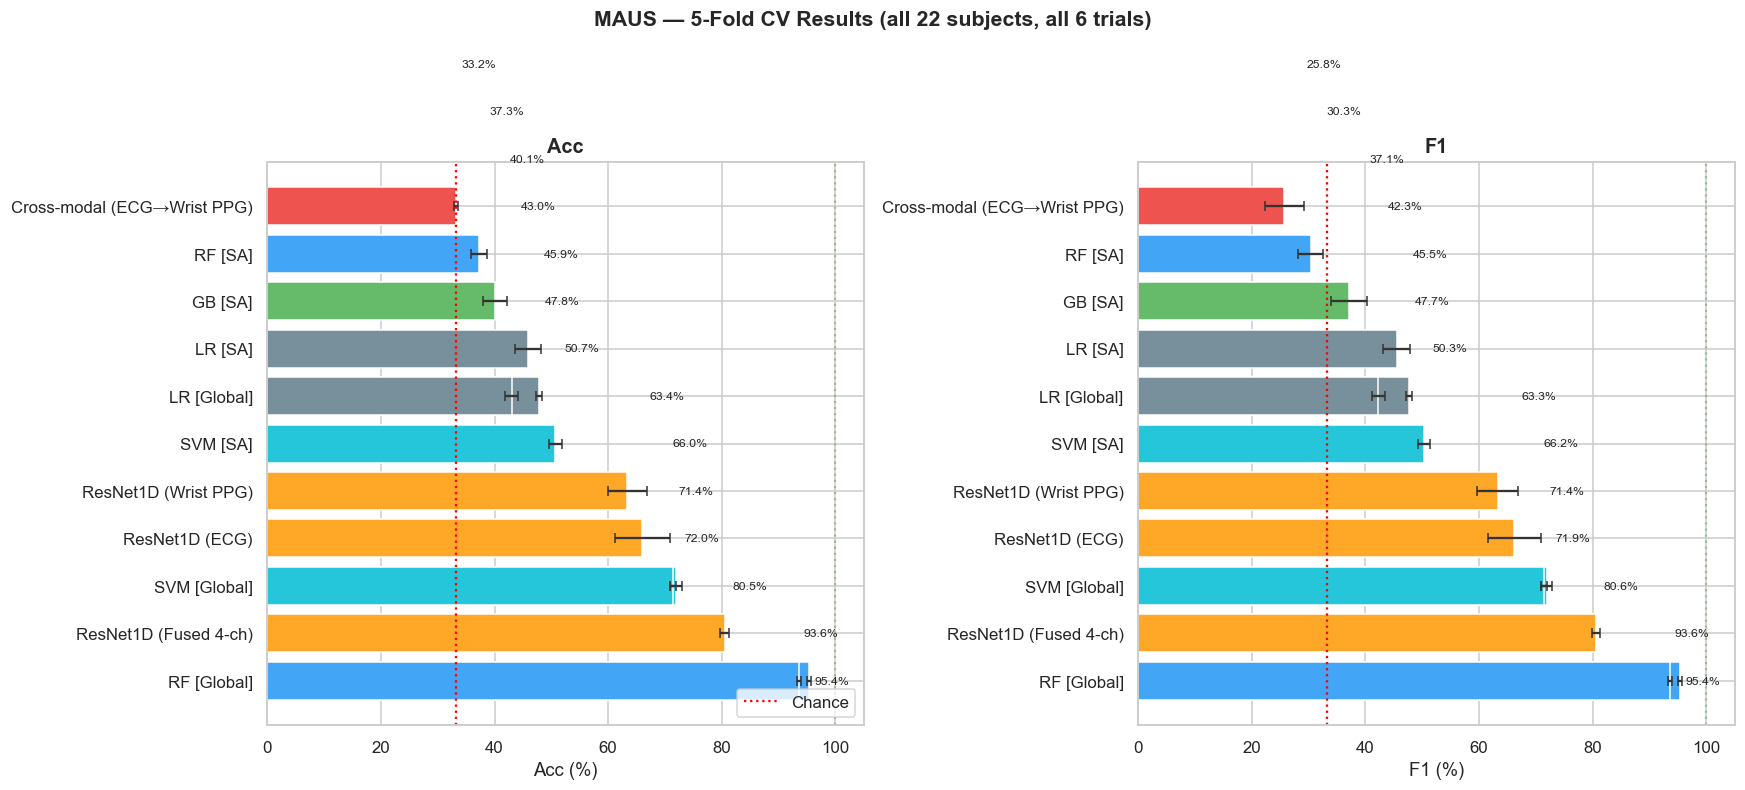

In [18]:
# ── Bar chart with error bars ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(results_cv)*0.45+1)))

palette = {'LR':'#78909C','RF':'#42A5F5','SVM':'#26C6DA','GB':'#66BB6A',
           'ResNet1D':'#FFA726','Cross':'#EF5350'}

def model_color(name):
    for k, c in palette.items():
        if k in name: return c
    return '#aaa'

for ax, metric, std_key in zip(axes,
    ['mean_acc','mean_f1'], ['std_acc','std_f1']):
    names  = [r['name'] for r in results_cv]
    vals   = [r[metric]*100 for r in results_cv]
    stds   = [r[std_key]*100 for r in results_cv]
    colors = [model_color(r['name']) for r in results_cv]
    # sort
    order  = np.argsort(vals)[::-1]
    names_ = [names[i] for i in order]
    vals_  = [vals[i]  for i in order]
    stds_  = [stds[i]  for i in order]
    cols_  = [colors[i] for i in order]

    ax.barh(names_, vals_, xerr=stds_, color=cols_, edgecolor='white',
            error_kw=dict(ecolor='#333', capsize=3))
    ax.set_xlim(0, 105)
    ax.axvline(33.3, color='red', linestyle=':', label='Chance')
    ax.axvline(100,  color='green', linestyle=':', alpha=0.3)
    ax.set_xlabel(f'{metric.replace("mean_","").capitalize()} (%)')
    ax.set_title(metric.replace('mean_','').capitalize(), fontsize=13, fontweight='bold')
    for i, (v, s) in enumerate(zip(vals_, stds_)):
        ax.text(v+s+0.5, i, f'{v:.1f}%', va='center', fontsize=8)

axes[0].legend(loc='lower right')
plt.suptitle('MAUS — 5-Fold CV Results (all 22 subjects, all 6 trials)',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


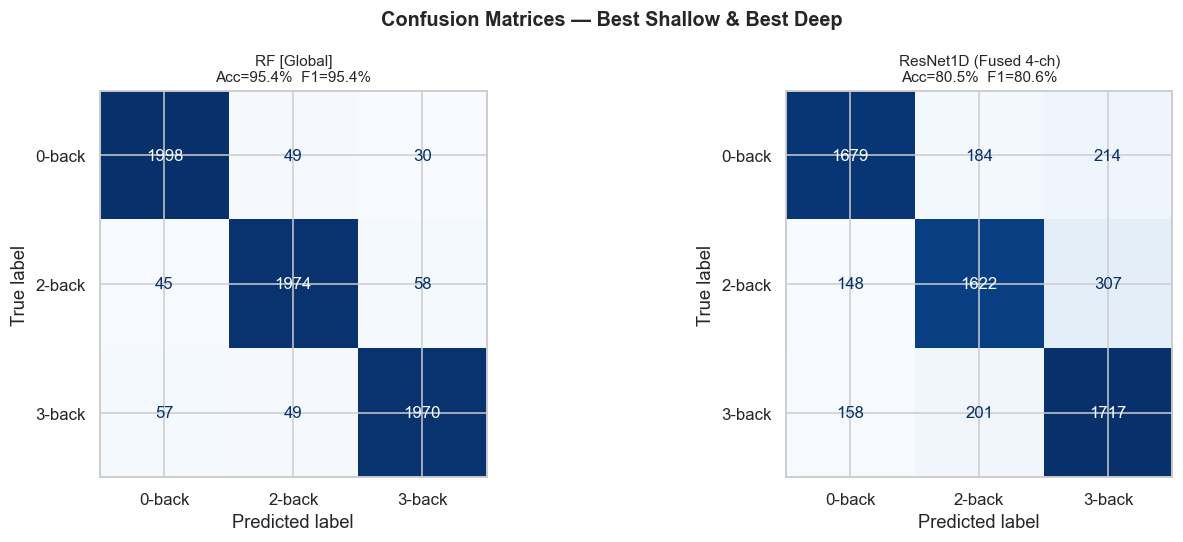

In [19]:
# ── Best shallow confusion matrix ─────────────────────────────────────
best = max(results_cv, key=lambda r: r['mean_acc'])
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, r in zip(axes, [best, r_fused]):
    acc = accuracy_score(r['all_true'], r['all_pred'])
    f1  = f1_score(r['all_true'], r['all_pred'], average='macro')
    ConfusionMatrixDisplay(
        confusion_matrix(r['all_true'], r['all_pred']),
        display_labels=CLASS_NAMES).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{r["name"]}\nAcc={acc*100:.1f}%  F1={f1*100:.1f}%', fontsize=10)
plt.suptitle('Confusion Matrices — Best Shallow & Best Deep', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


In [20]:
# ── Final text summary ────────────────────────────────────────────────
best   = max(results_cv, key=lambda r: r['mean_acc'])
worst  = min(results_cv, key=lambda r: r['mean_acc'])

print('\n' + '='*68)
print('  MAUS — WITHIN-TRIAL 5-FOLD CV  FINAL SUMMARY')
print('='*68)
for r in sorted(results_cv, key=lambda x: -x['mean_acc']):
    print(f"  {r['name']:<38s}  Acc={r['mean_acc']*100:.1f}±{r['std_acc']*100:.1f}%  "          f"F1={r['mean_f1']*100:.1f}±{r['std_f1']*100:.1f}%")
print('='*68)
print(f'\n🏆 Best model : {best["name"]}')
print(f'   CV Accuracy : {best["mean_acc"]*100:.1f} ± {best["std_acc"]*100:.1f}%')
print(f'   CV F1       : {best["mean_f1"]*100:.1f} ± {best["std_f1"]*100:.1f}%')
ecg_acc  = next(r for r in results_cv if 'ECG' in r['name'] and 'Cross' not in r['name'])['mean_acc']
cross_acc = r_cross['mean_acc']
print(f"\n📉 Cross-modal gap : {ecg_acc*100:.1f}% (ECG) → {cross_acc*100:.1f}% (ECG→Wrist PPG) "      f"= {(ecg_acc-cross_acc)*100:.1f}% penalty")
print(f'\n🛡️  Conformal APS (α={ALPHA}):')
print(f'   τ = {tau:.4f}   Coverage = {cov*100:.1f}%   Avg |S| = {avg_sz:.2f}')
print(f'   Size dist: {{1}}: {sz_d[1]}  {{2}}: {sz_d[2]}  {{3}}: {sz_d[3]}')
print(f'\n📌 Protocol: 5-fold stratified CV on all windows;')
print(f'   conformal on separate 80/10/10 fixed holdout (guarantee is valid).')



  MAUS — WITHIN-TRIAL 5-FOLD CV  FINAL SUMMARY
  RF [Global]                             Acc=95.4±0.4%  F1=95.4±0.4%
  RF [Global]                             Acc=93.6±0.3%  F1=93.6±0.3%
  ResNet1D (Fused 4-ch)                   Acc=80.5±0.8%  F1=80.6±0.8%
  SVM [Global]                            Acc=72.0±1.0%  F1=71.9±1.0%
  SVM [Global]                            Acc=71.4±0.5%  F1=71.4±0.6%
  ResNet1D (ECG)                          Acc=66.0±4.8%  F1=66.2±4.7%
  ResNet1D (Wrist PPG)                    Acc=63.4±3.4%  F1=63.3±3.6%
  SVM [SA]                                Acc=50.7±1.1%  F1=50.3±1.0%
  LR [Global]                             Acc=47.8±0.5%  F1=47.7±0.5%
  LR [SA]                                 Acc=45.9±2.3%  F1=45.5±2.4%
  LR [Global]                             Acc=43.0±1.1%  F1=42.3±1.2%
  GB [SA]                                 Acc=40.1±2.1%  F1=37.1±3.1%
  RF [SA]                                 Acc=37.3±1.4%  F1=30.3±2.2%
  Cross-modal (ECG→Wrist PPG)             